In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000084674""","""ldl_direct_int""",2.2543e-301,-0.12678,0.12678,-1.0
"""ENSG00000167701""","""alanine_aminotransferase_int""",1.2234e-144,-0.106424,0.106424,-1.0
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…",9.8993e-24,-0.100921,0.100921,-1.0
"""ENSG00000141505""","""alkaline_phosphatase_int""",8.4146e-35,0.089171,0.089171,1.0
"""ENSG00000101162""","""platelet_distribution_width_in…",1.5335e-83,0.08869,0.08869,1.0
…,…,…,…,…,…
"""ENSG00000115977""","""sitting_height_int""",0.021257,-0.001496,0.001496,-1.0
"""ENSG00000119574""","""standing_height_int""",0.025535,-0.001317,0.001317,-1.0
"""ENSG00000115325""","""platelet_distribution_width_in…",0.01277,-0.001204,0.001204,-1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [4]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)),
        # (pl.col('non_mane_cds')==False),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),
        # (pl.col('consequence_5_prime_utr_variant') == True),
        # (pl.col('consequence_upstream_gene_variant') == True),
        # (pl.col('consequence_downstream_gene_variant') == True),
        # (pl.col('consequence_intron_variant') == True),

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Custom variant class filter
        # (pl.col('relative_cds_position')>=0.5),

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range),
        # (pl.col('dist_to_tss') <= max_range),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # ADD TO ANNOTATIONS NOTEBOOK
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_annotated_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_full_lip_priority']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

# selected_categories = ['vep_consequences'] # VEP CDS consequences
# selected_categories = ['plof_consequences'] # VEP plof consequences
# selected_categories = ['plof', 'missense', 'conservation', 'splicing'] # Gene-Body
selected_categories = ['missense'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'] # non coding
# selected_categories = ['encode_regions'] # encode regions
# selected_categories = ['encode_custom'] # encode regions custom
# selected_categories = ['conservation', 'regulatory_nondir', 'genetic_diversity'] # 5UTR

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    .fill_null(0) # For CPT1 LLR, ESM1B LLR, and REVEL
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_390749/3179774819.py:85: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_390749/3179774819.py:94: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


am_pathogenicity,region,cpt1_llr,esm1b_llr,revel_score,id,esmscoremissense
f32,str,f64,f64,f64,str,f32
0.7173,"""ENSG00000175426""",0.225474,-7.053,0.152,"""chr5:96432941:T:G""",-5.254
0.2781,"""ENSG00000109111""",0.27106,-6.579,0.104,"""chr17:28700367:C:T""",-6.218
0.0782,"""ENSG00000008710""",0.212085,-5.308,0.119,"""chr16:2092095:G:C""",-2.585
0.0,"""ENSG00000112541""",0.0,0.0,0.608,"""chr6:165416273:A:G""",-6.679
0.383,"""ENSG00000197321""",0.124594,-8.595,0.211,"""chr10:29463575:T:C""",-3.547
…,…,…,…,…,…,…
0.0891,"""ENSG00000141279""",0.095963,-5.92,0.124,"""chr17:47596446:A:G""",-3.925
0.9695,"""ENSG00000131467""",0.093516,-2.447,0.102,"""chr17:42838105:T:C""",-2.232
0.9695,"""ENSG00000131467""",0.0,0.0,0.102,"""chr17:42838105:T:C""",-2.232


In [5]:
# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == 1
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr5:96432941:T:G""","""ENSG00000175426""","""am_pathogenicity""",0.7173
"""chr17:28700367:C:T""","""ENSG00000109111""","""am_pathogenicity""",0.2781
"""chr16:2092095:G:C""","""ENSG00000008710""","""am_pathogenicity""",0.0782
"""chr6:165416273:A:G""","""ENSG00000112541""","""am_pathogenicity""",0.0
"""chr10:29463575:T:C""","""ENSG00000197321""","""am_pathogenicity""",0.383
…,…,…,…
"""chr17:47596446:A:G""","""ENSG00000141279""","""esmscoremissense""",-3.925
"""chr17:42838105:T:C""","""ENSG00000131467""","""esmscoremissense""",-2.232
"""chr17:42838105:T:C""","""ENSG00000131467""","""esmscoremissense""",-2.232


In [6]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


In [7]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Build the main lazy query plan
# Join order: appv → id_region (adds region) → gene_trait_df (filter early) → melted_anno (annotation scores)
final_lazy_plan = (
    appv
    .join(id_region, on='id', how='inner')
    .join(
        gene_trait_df[["region", "phenotype"]].lazy(),
        on=["region", "phenotype"],
        how="inner"
    )
    .join(
        melted_anno.lazy(),
        on=["id", "region"],
        how="inner"
    )

    # Spearman: rank with "average" for proper tie handling
    .with_columns(
        pl.col(c)
        .rank("average")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None)
    )

    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
        
    .collect(engine='streaming')
)

# Join with beta directions and annotation directions
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (3268, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000136383""","""leg_predicted_mass_left_int""","""esmscoremissense""",808,0.021568,"""#feb72d""","""ESM1v""",-1,0.047522,-0.003374,0.003374,-1.0,0.021568,6.392605
"""ENSG00000148584""","""gamma_glutamyltransferase_int""","""am_pathogenicity""",224,0.179056,"""#feb72d""","""AlphaMissense""",1,0.000002,0.019667,0.019667,1.0,0.179056,9.104576
"""ENSG00000142303""","""standing_height_int""","""am_pathogenicity""",489,-0.232385,"""#feb72d""","""AlphaMissense""",1,1.3236e-17,-0.061587,0.061587,-1.0,0.232385,3.77326
"""ENSG00000107099""","""mean_platelet_thrombocyte_volu…","""esm1b_llr""",1164,0.037964,"""#feb72d""","""ESM1b""",-1,0.000133,-0.007464,0.007464,-1.0,0.037964,5.086506
"""ENSG00000149100""","""mean_corpuscular_haemoglobin_i…","""esmscoremissense""",141,0.059123,"""#feb72d""","""ESM1v""",-1,0.000427,-0.050843,0.050843,-1.0,0.059123,1.162855
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000058600""","""forced_vital_capacity_fvc_int""","""cpt1_llr""",354,-0.094931,"""#feb72d""","""CPT-1""",1,0.023085,-0.006863,0.006863,-1.0,0.094931,13.831442
"""ENSG00000025434""","""hdl_cholesterol_int""","""am_pathogenicity""",197,0.165352,"""#feb72d""","""AlphaMissense""",1,0.000703,0.025263,0.025263,1.0,0.165352,6.545123
"""ENSG00000132170""","""hdl_cholesterol_int""","""esm1b_llr""",153,-0.027725,"""#feb72d""","""ESM1b""",-1,0.000122,-0.021474,0.021474,-1.0,-0.027725,-1.291126


In [8]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000148584""","""gamma_glutamyltransferase_int""","""am_pathogenicity""",224,0.179056,"""#feb72d""","""AlphaMissense""",1,0.000002,0.019667,0.019667,1.0,0.179056,9.104576,5
"""ENSG00000107099""","""mean_platelet_thrombocyte_volu…","""esm1b_llr""",1164,0.037964,"""#feb72d""","""ESM1b""",-1,0.000133,-0.007464,0.007464,-1.0,0.037964,5.086506,5
"""ENSG00000149100""","""mean_corpuscular_haemoglobin_i…","""esmscoremissense""",141,0.059123,"""#feb72d""","""ESM1v""",-1,0.000427,-0.050843,0.050843,-1.0,0.059123,1.162855,5
"""ENSG00000056586""","""forced_expiratory_volume_in_1s…","""revel_score""",455,-0.017952,"""#feb72d""","""REVEL""",1,0.045758,-0.01012,0.01012,-1.0,0.017952,1.773879,5
"""ENSG00000025708""","""mean_reticulocyte_volume_int""","""cpt1_llr""",318,-0.153079,"""#feb72d""","""CPT-1""",1,0.043691,-0.037101,0.037101,-1.0,0.153079,4.125997,5
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000103657""","""standing_height_int""","""esm1b_llr""",2081,0.003407,"""#feb72d""","""ESM1b""",-1,0.000642,0.018111,0.018111,1.0,-0.003407,-0.188138,5
"""ENSG00000164329""","""sitting_height_int""","""am_pathogenicity""",193,0.150196,"""#feb72d""","""AlphaMissense""",1,0.040021,0.006862,0.006862,1.0,0.150196,21.887883,5
"""ENSG00000058600""","""forced_vital_capacity_fvc_int""","""cpt1_llr""",354,-0.094931,"""#feb72d""","""CPT-1""",1,0.023085,-0.006863,0.006863,-1.0,0.094931,13.831442,5


In [9]:
consistent_gt.sort('n_annotations', descending=True)

region,phenotype,n_annotations
str,str,u64
"""ENSG00000170927""","""gamma_glutamyltransferase_int""",5
"""ENSG00000175426""","""waist_circumference_int""",5
"""ENSG00000072778""","""mean_reticulocyte_volume_int""",5
"""ENSG00000167325""","""mean_corpuscular_volume_int""",5
"""ENSG00000005961""","""platelet_count_int""",5
…,…,…
"""ENSG00000197969""","""mean_sphered_cell_volume_int""",5
"""ENSG00000164163""","""mean_sphered_cell_volume_int""",5
"""ENSG00000165029""","""apolipoprotein_a_int""",5


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


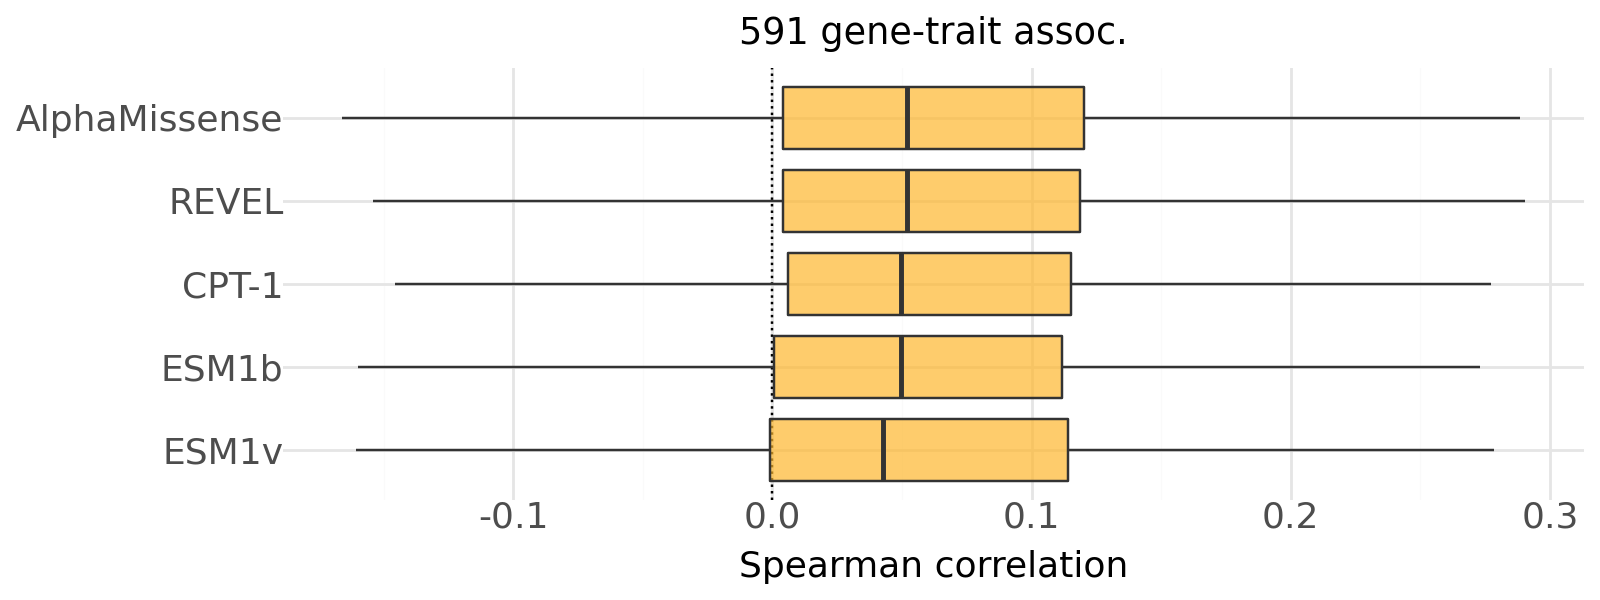

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pl[['region', 'phenotype']].unique().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [12]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_390749/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""esm1b_llr""","""cpt1_llr""",591,67920.0,0.000003
"""esmscoremissense""","""cpt1_llr""",591,68419.0,0.000004
"""esm1b_llr""","""am_pathogenicity""",591,71122.0,0.000083
"""esmscoremissense""","""am_pathogenicity""",591,73929.0,0.001113
"""esmscoremissense""","""revel_score""",591,77603.0,0.017525
"""esm1b_llr""","""revel_score""",591,79164.0,0.045542
